# 08. Weather Context Analysis

This notebook analyzes weather context variables collected for each lotto draw.

Main goals:

- inspect the distribution and data quality of weather variables
- compare lotto pattern variables across weather conditions
- check whether weather-condition groups show visibly different number distributions
- save report-ready figures and tables when needed


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
candidates = [cwd, *cwd.parents]
PROJECT_ROOT = None
for candidate in candidates:
    if (candidate / "src").exists() and (candidate / "data").exists():
        PROJECT_ROOT = candidate
        break
    if (candidate / "app" / "src").exists() and (candidate / "app" / "data").exists():
        PROJECT_ROOT = candidate / "app"
        break

if PROJECT_ROOT is None:
    raise RuntimeError(f"Could not locate app root from {cwd}")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/workspace')

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from src.config import WEATHER_CONTEXT_FILE, PROCESSED_LOTTO_FILE

try:
    from src.visualization import save_report_figure, save_report_table
except Exception:
    save_report_figure = None
    save_report_table = None

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 200)

In [3]:
weather_df = pd.read_csv(WEATHER_CONTEXT_FILE, low_memory=False)
lotto_df = pd.read_csv(PROCESSED_LOTTO_FILE, low_memory=False)

weather_df["draw_date"] = pd.to_datetime(weather_df["draw_date"], errors="coerce")
weather_df["draw_datetime_used"] = pd.to_datetime(weather_df["draw_datetime_used"], errors="coerce")

merged_df = lotto_df.merge(weather_df, on="round", how="inner", suffixes=("", "_weather"))
merged_df.shape

(1217, 39)

In [4]:
weather_numeric_cols = [
    "temp_at_draw",
    "humidity_at_draw",
    "wind_at_draw",
    "pressure_at_draw",
    "snow_at_draw",
    "precip_1h",
    "precip_6h",
    "precip_24h",
    "daily_tavg",
    "daily_tmin",
    "daily_tmax",
    "daily_precip_mm",
]

for col in weather_numeric_cols:
    if col in merged_df.columns:
        merged_df[col] = pd.to_numeric(merged_df[col], errors="coerce")

# KMA sentinel cleanup
for col in ["precip_1h", "precip_6h", "precip_24h", "daily_precip_mm", "snow_at_draw"]:
    if col in merged_df.columns:
        merged_df.loc[merged_df[col] < 0, col] = np.nan

for col in ["temp_at_draw", "humidity_at_draw", "wind_at_draw", "pressure_at_draw"]:
    if col in merged_df.columns:
        merged_df.loc[merged_df[col] <= -90, col] = np.nan

merged_df["rain_flag"] = merged_df["is_raining"].fillna(False).astype(bool)
merged_df["snow_flag"] = merged_df["is_snowing"].fillna(False).astype(bool)

valid_temp = merged_df["temp_at_draw"].dropna()
if len(valid_temp) >= 8:
    merged_df["temp_quartile"] = pd.qcut(merged_df["temp_at_draw"], q=4, duplicates="drop")
else:
    merged_df["temp_quartile"] = pd.NA

valid_humidity = merged_df["humidity_at_draw"].dropna()
if len(valid_humidity) >= 8:
    merged_df["humidity_quartile"] = pd.qcut(merged_df["humidity_at_draw"], q=4, duplicates="drop")
else:
    merged_df["humidity_quartile"] = pd.NA

merged_df[["round", "temp_at_draw", "humidity_at_draw", "wind_at_draw", "pressure_at_draw", "precip_1h"]].head()

,round,temp_at_draw,humidity_at_draw,wind_at_draw,pressure_at_draw,precip_1h
0,1,5.1,55.0,3.5,1015.5,0.0
1,2,2.3,60.0,2.0,1021.5,0.0
2,3,6.8,62.0,3.5,1015.2,0.0
3,4,0.0,64.0,4.4,1011.4,0.0
4,5,-12.1,59.0,3.8,1014.8,0.0


## Data Quality Overview

In [5]:
quality_summary = pd.DataFrame({
    "non_null": merged_df[weather_numeric_cols].notna().sum(),
    "missing": merged_df[weather_numeric_cols].isna().sum(),
    "missing_ratio": merged_df[weather_numeric_cols].isna().mean().round(4),
}).sort_index()
quality_summary

,non_null,missing,missing_ratio
daily_precip_mm,0,1217,1.0000
daily_tavg,0,1217,1.0000
daily_tmax,0,1217,1.0000
daily_tmin,0,1217,1.0000
humidity_at_draw,1217,0,0.0000
precip_1h,1217,0,0.0000
precip_24h,1217,0,0.0000
precip_6h,1217,0,0.0000
pressure_at_draw,1217,0,0.0000
snow_at_draw,7,1210,0.9942


## Weather Variable Distributions

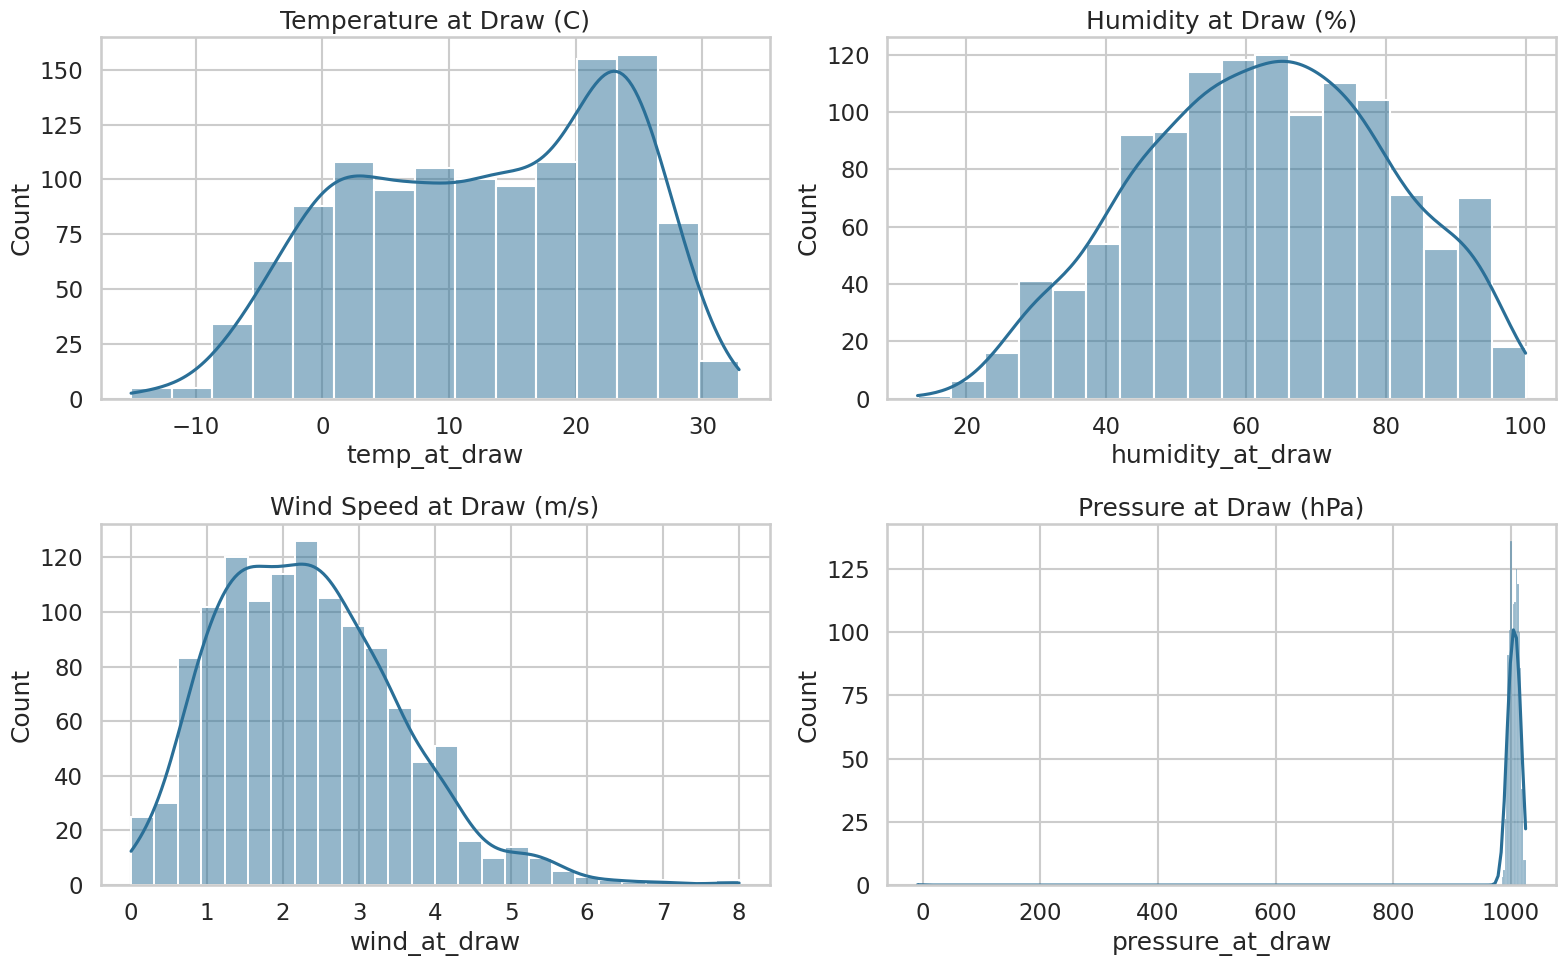

In [6]:
fig_weather_dist, axes = plt.subplots(2, 2, figsize=(16, 10))
plot_specs = [
    ("temp_at_draw", "Temperature at Draw (C)"),
    ("humidity_at_draw", "Humidity at Draw (%)"),
    ("wind_at_draw", "Wind Speed at Draw (m/s)"),
    ("pressure_at_draw", "Pressure at Draw (hPa)"),
]
for ax, (col, title) in zip(axes.flat, plot_specs):
    sns.histplot(merged_df[col].dropna(), kde=True, ax=ax, color="#2a6f97")
    ax.set_title(title)
plt.tight_layout()
plt.show()

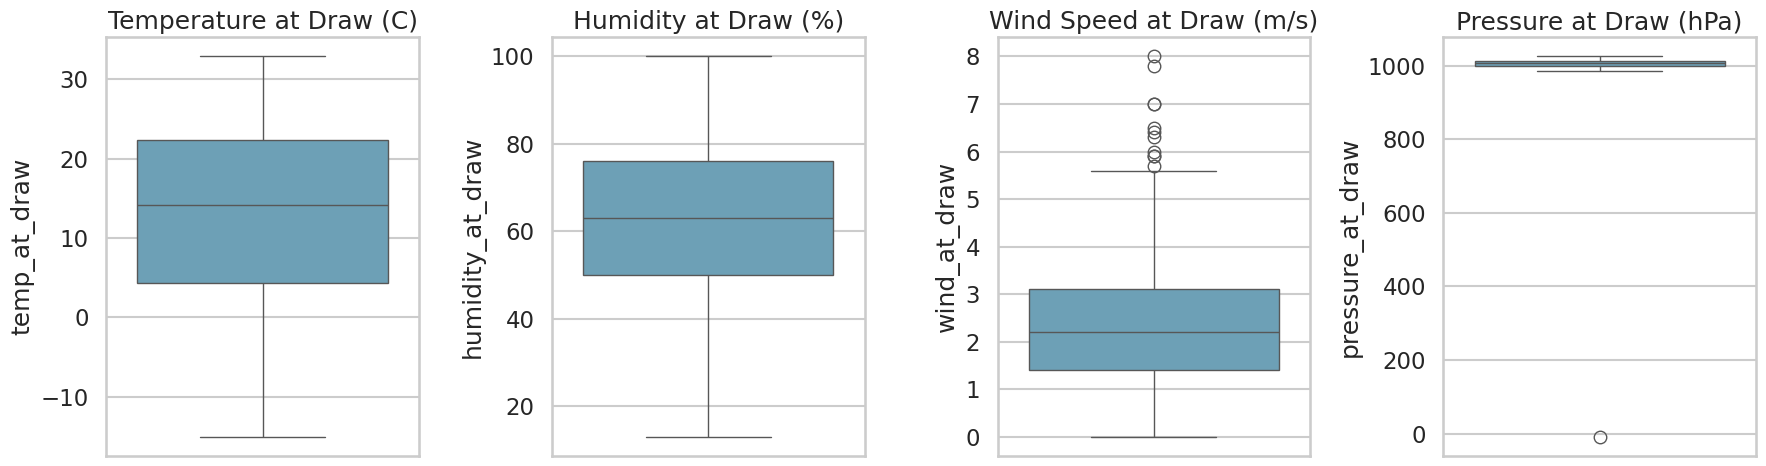

In [7]:
fig_weather_box, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (col, title) in zip(axes, plot_specs):
    sns.boxplot(y=merged_df[col], ax=ax, color="#61a5c2")
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Rain / Snow Occurrence

In [8]:
occurrence_summary = pd.DataFrame({
    "count": [merged_df["rain_flag"].sum(), merged_df["snow_flag"].sum()],
    "ratio": [merged_df["rain_flag"].mean(), merged_df["snow_flag"].mean()],
}, index=["rain_flag", "snow_flag"])
occurrence_summary

,count,ratio
rain_flag,0,0.00000
snow_flag,6,0.00493


/tmp/ipykernel_20/3166472164.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=merged_df["rain_flag"], ax=axes[0], palette="Blues")
/tmp/ipykernel_20/3166472164.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=merged_df["snow_flag"], ax=axes[1], palette="Greys")


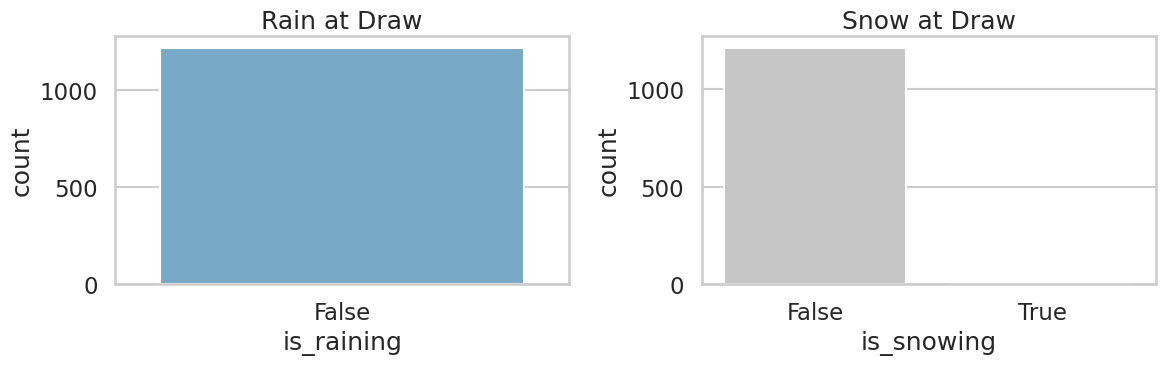

In [9]:
fig_occurrence, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=merged_df["rain_flag"], ax=axes[0], palette="Blues")
axes[0].set_title("Rain at Draw")
axes[0].set_xlabel("is_raining")

sns.countplot(x=merged_df["snow_flag"], ax=axes[1], palette="Greys")
axes[1].set_title("Snow at Draw")
axes[1].set_xlabel("is_snowing")
plt.tight_layout()
plt.show()

## Lotto Pattern Comparisons by Weather Condition

In [10]:
pattern_cols = ["sum_main", "odd_count", "low_count"]
pattern_cols

['sum_main', 'odd_count', 'low_count']

/tmp/ipykernel_20/1755261075.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x="temp_bin", y=col, ax=ax, palette="coolwarm")
/tmp/ipykernel_20/1755261075.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x="temp_bin", y=col, ax=ax, palette="coolwarm")
/tmp/ipykernel_20/1755261075.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x="temp_bin", y=col, ax=ax, palette="coolwarm")


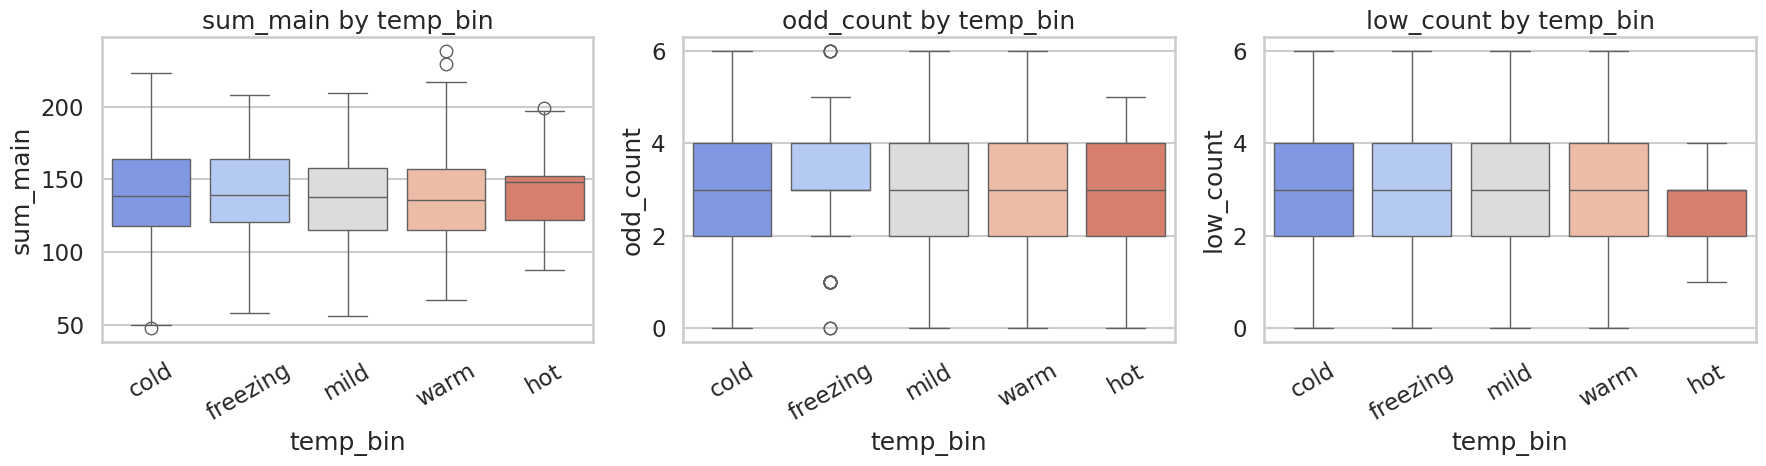

In [11]:
fig_temp_patterns, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, pattern_cols):
    sns.boxplot(data=merged_df, x="temp_bin", y=col, ax=ax, palette="coolwarm")
    ax.set_title(f"{col} by temp_bin")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

/tmp/ipykernel_20/1427819932.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x="humidity_bin", y=col, ax=ax, palette="YlGnBu")
/tmp/ipykernel_20/1427819932.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x="humidity_bin", y=col, ax=ax, palette="YlGnBu")
/tmp/ipykernel_20/1427819932.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x="humidity_bin", y=col, ax=ax, palette="YlGnBu")


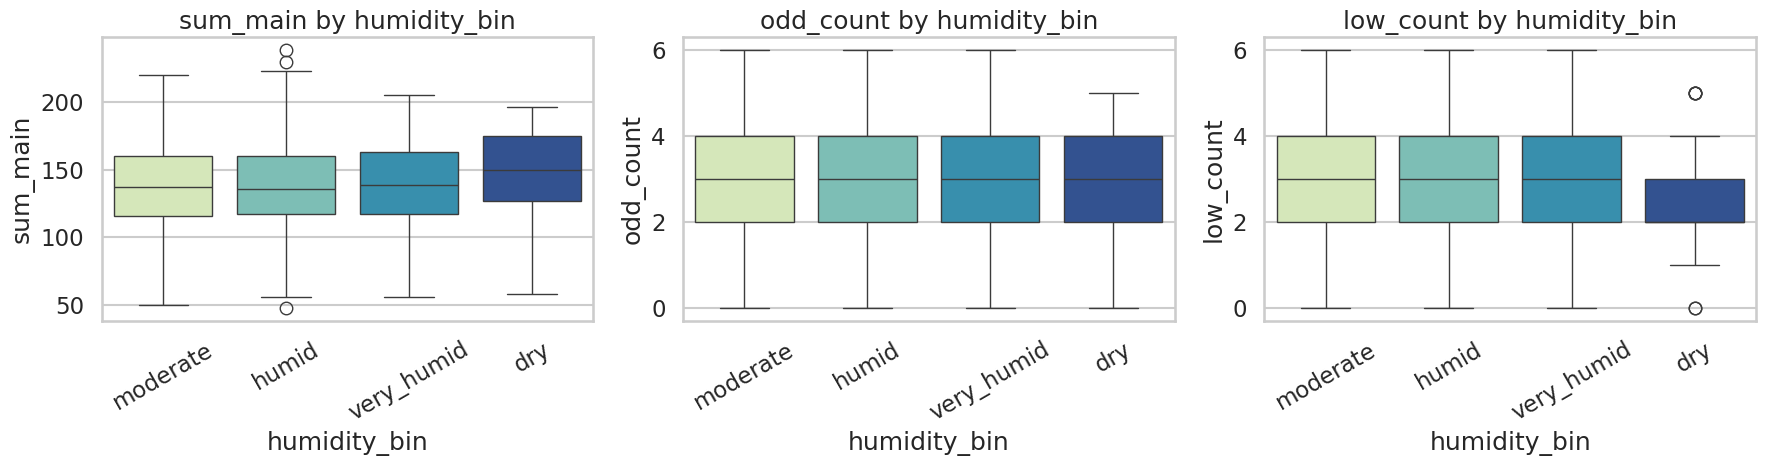

In [12]:
fig_humidity_patterns, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, pattern_cols):
    sns.boxplot(data=merged_df, x="humidity_bin", y=col, ax=ax, palette="YlGnBu")
    ax.set_title(f"{col} by humidity_bin")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

/tmp/ipykernel_20/3565505591.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x=flag_col, y=target_col, ax=axes[idx, jdx], palette="Set2")
/tmp/ipykernel_20/3565505591.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x=flag_col, y=target_col, ax=axes[idx, jdx], palette="Set2")
/tmp/ipykernel_20/3565505591.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x=flag_col, y=target_col, ax=axes[idx, jdx], palette="Set2")
/tmp/ipykernel_20/3565505591.py:4: FutureWarning: 

Passing `palette` wit

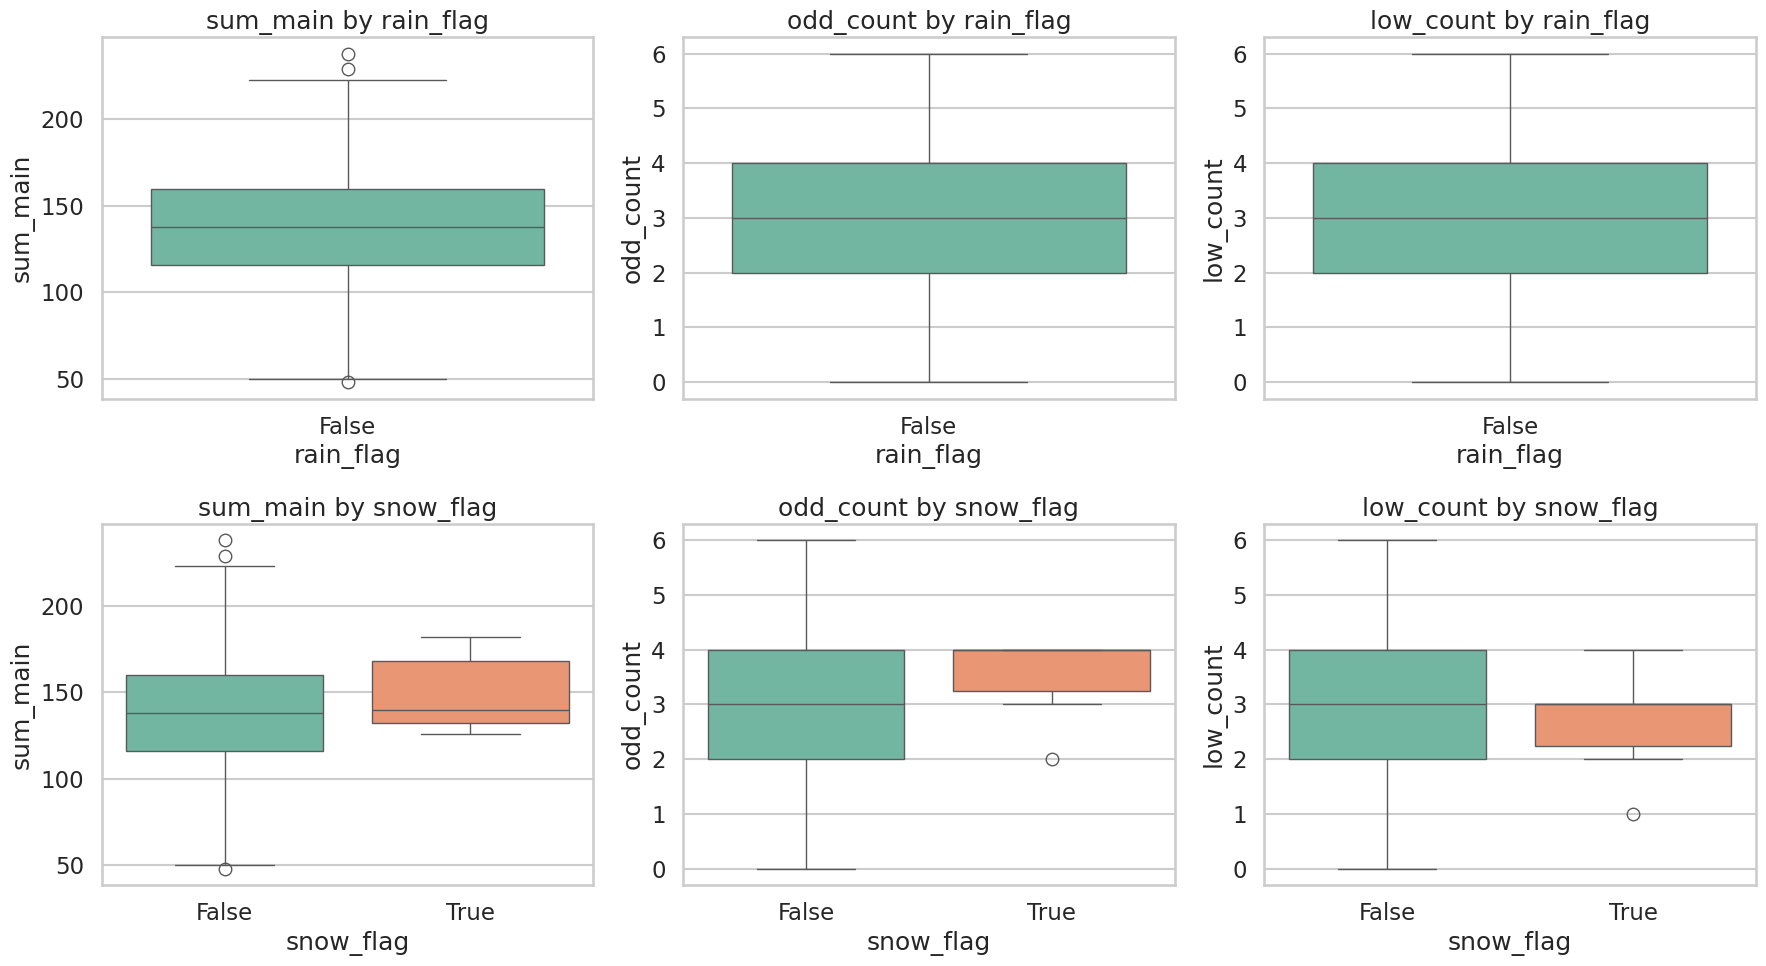

In [13]:
fig_binary_patterns, axes = plt.subplots(2, 3, figsize=(18, 10))
for idx, flag_col in enumerate(["rain_flag", "snow_flag"]):
    for jdx, target_col in enumerate(pattern_cols):
        sns.boxplot(data=merged_df, x=flag_col, y=target_col, ax=axes[idx, jdx], palette="Set2")
        axes[idx, jdx].set_title(f"{target_col} by {flag_col}")
plt.tight_layout()
plt.show()

## Number Frequency by Weather Group

In [14]:
number_long = merged_df[["round", "temp_bin", "humidity_bin", "rain_flag", "snow_flag", "n1", "n2", "n3", "n4", "n5", "n6"]].melt(
    id_vars=["round", "temp_bin", "humidity_bin", "rain_flag", "snow_flag"],
    value_vars=["n1", "n2", "n3", "n4", "n5", "n6"],
    var_name="position",
    value_name="number",
)
number_long.head()

,round,temp_bin,humidity_bin,rain_flag,snow_flag,position,number
0,1,cold,moderate,False,False,n1,10
1,2,cold,humid,False,False,n1,9
2,3,cold,humid,False,False,n1,11
3,4,cold,humid,False,False,n1,14
4,5,freezing,moderate,False,False,n1,16


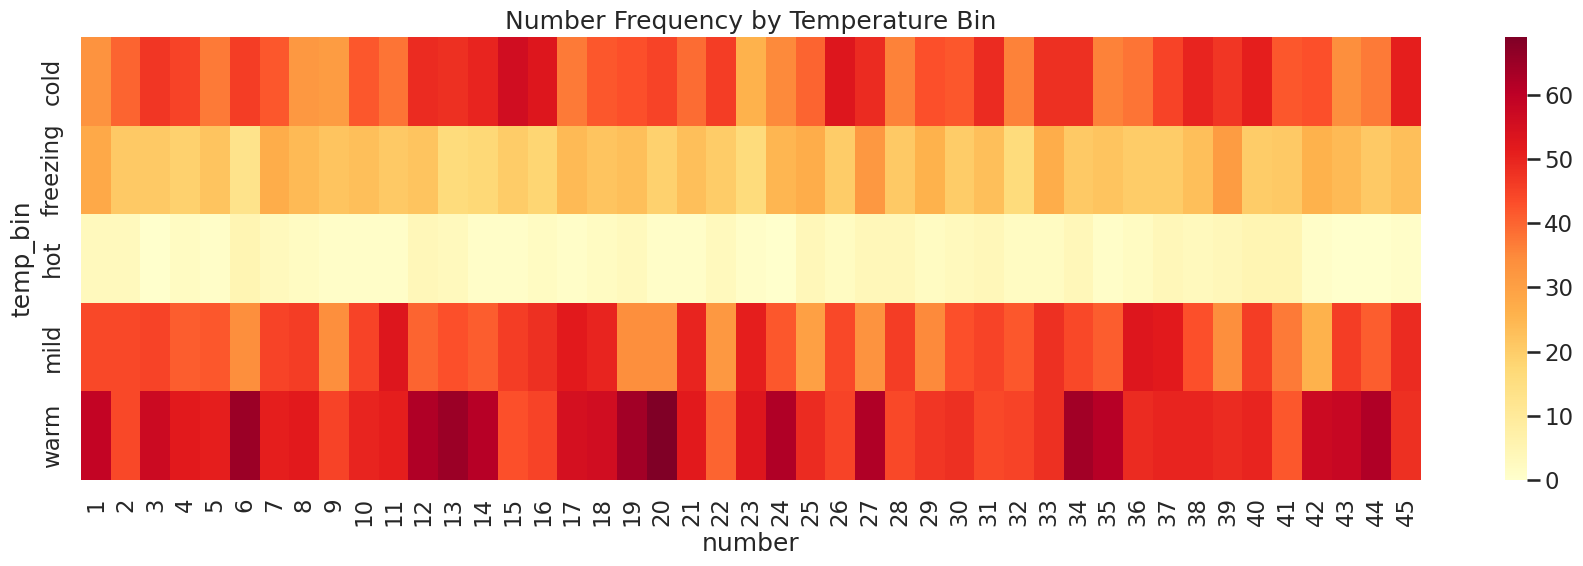

In [15]:
temp_freq = (
    number_long.dropna(subset=["temp_bin", "number"])
    .groupby(["temp_bin", "number"]).size()
    .unstack(fill_value=0)
)
fig_temp_heatmap, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(temp_freq, cmap="YlOrRd", ax=ax)
ax.set_title("Number Frequency by Temperature Bin")
plt.tight_layout()
plt.show()

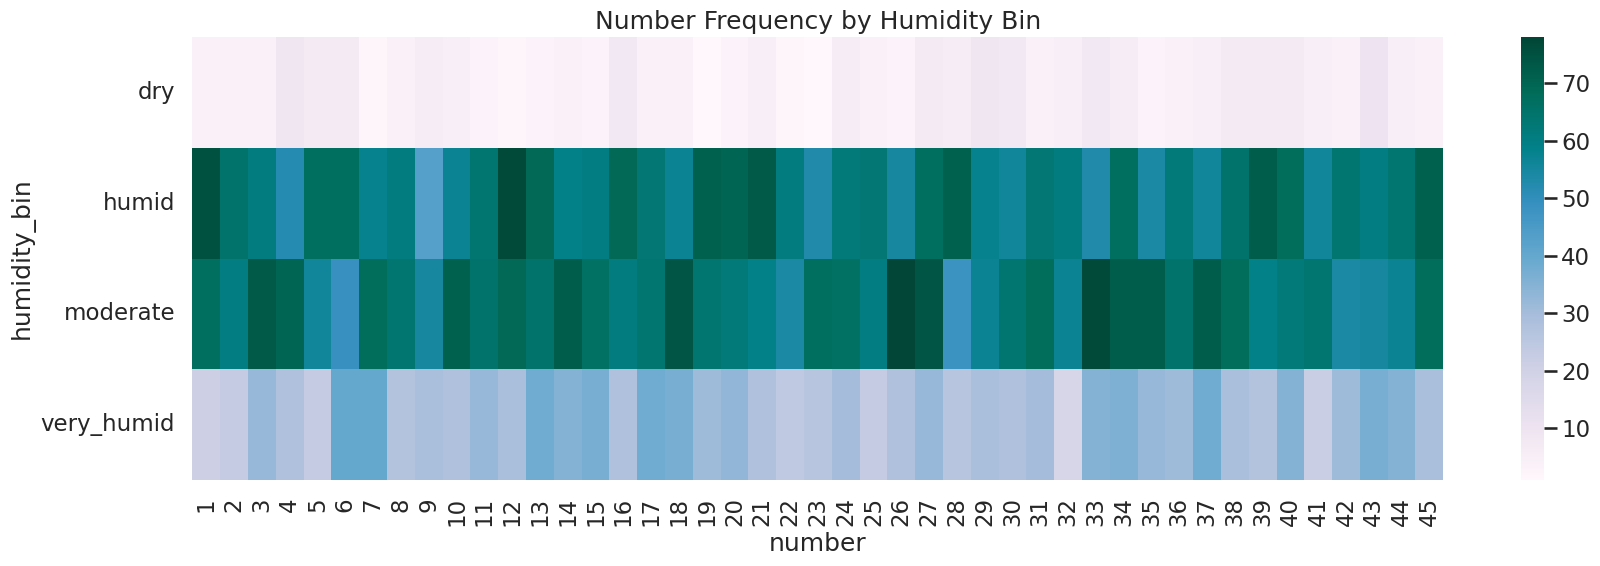

In [16]:
humidity_freq = (
    number_long.dropna(subset=["humidity_bin", "number"])
    .groupby(["humidity_bin", "number"]).size()
    .unstack(fill_value=0)
)
fig_humidity_heatmap, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(humidity_freq, cmap="PuBuGn", ax=ax)
ax.set_title("Number Frequency by Humidity Bin")
plt.tight_layout()
plt.show()

## Simple Statistical Tests

In [17]:
test_rows = []

for target_col in pattern_cols:
    temp_groups = [g[target_col].dropna().values for _, g in merged_df.groupby("temp_bin") if len(g[target_col].dropna()) > 0]
    if len(temp_groups) >= 2:
        stat, p = stats.kruskal(*temp_groups)
        test_rows.append({"group": "temp_bin", "target": target_col, "test": "kruskal", "stat": stat, "p_value": p})

    humidity_groups = [g[target_col].dropna().values for _, g in merged_df.groupby("humidity_bin") if len(g[target_col].dropna()) > 0]
    if len(humidity_groups) >= 2:
        stat, p = stats.kruskal(*humidity_groups)
        test_rows.append({"group": "humidity_bin", "target": target_col, "test": "kruskal", "stat": stat, "p_value": p})

    rain_groups = [g[target_col].dropna().values for _, g in merged_df.groupby("rain_flag") if len(g[target_col].dropna()) > 0]
    if len(rain_groups) == 2:
        stat, p = stats.mannwhitneyu(rain_groups[0], rain_groups[1], alternative="two-sided")
        test_rows.append({"group": "rain_flag", "target": target_col, "test": "mannwhitneyu", "stat": stat, "p_value": p})

    snow_groups = [g[target_col].dropna().values for _, g in merged_df.groupby("snow_flag") if len(g[target_col].dropna()) > 0]
    if len(snow_groups) == 2:
        stat, p = stats.mannwhitneyu(snow_groups[0], snow_groups[1], alternative="two-sided")
        test_rows.append({"group": "snow_flag", "target": target_col, "test": "mannwhitneyu", "stat": stat, "p_value": p})

weather_test_summary = pd.DataFrame(test_rows).sort_values(["group", "target"]).reset_index(drop=True)
weather_test_summary

,group,target,test,stat,p_value
0,humidity_bin,low_count,kruskal,4.918571,0.177858
1,humidity_bin,odd_count,kruskal,1.520018,0.677658
2,humidity_bin,sum_main,kruskal,3.759501,0.288632
3,snow_flag,low_count,mannwhitneyu,4058.500000,0.609041
4,snow_flag,odd_count,mannwhitneyu,2725.000000,0.273569
5,snow_flag,sum_main,mannwhitneyu,2866.000000,0.372071
6,temp_bin,low_count,kruskal,4.719070,0.317356
7,temp_bin,odd_count,kruskal,7.238913,0.123789
8,temp_bin,sum_main,kruskal,3.537068,0.472265


## Report Export

In [18]:
if save_report_figure is not None and save_report_table is not None:
    save_report_figure(fig_weather_dist, "fig_18_weather_distribution.png")
    save_report_figure(fig_weather_box, "fig_19_weather_boxplots.png")
    save_report_figure(fig_occurrence, "fig_20_weather_occurrence.png")
    save_report_figure(fig_temp_patterns, "fig_21_weather_temp_pattern_boxplots.png")
    save_report_figure(fig_humidity_patterns, "fig_22_weather_humidity_pattern_boxplots.png")
    save_report_figure(fig_binary_patterns, "fig_23_weather_binary_pattern_boxplots.png")
    save_report_figure(fig_temp_heatmap, "fig_24_weather_temp_number_heatmap.png")
    save_report_figure(fig_humidity_heatmap, "fig_25_weather_humidity_number_heatmap.png")

    save_report_table(quality_summary.reset_index(names="variable"), "table_15_weather_quality_summary.csv")
    save_report_table(occurrence_summary.reset_index(names="flag"), "table_16_weather_occurrence_summary.csv")
    save_report_table(weather_test_summary, "table_17_weather_pattern_test_summary.csv")
    save_report_table(temp_freq.reset_index(), "table_18_weather_temp_number_frequency.csv")
    save_report_table(humidity_freq.reset_index(), "table_19_weather_humidity_number_frequency.csv")
    print("Weather report artifacts saved.")
else:
    print("Report export helpers are not available in this environment.")

Weather report artifacts saved.
